Dataset contains complete sequences. No missing records detected.


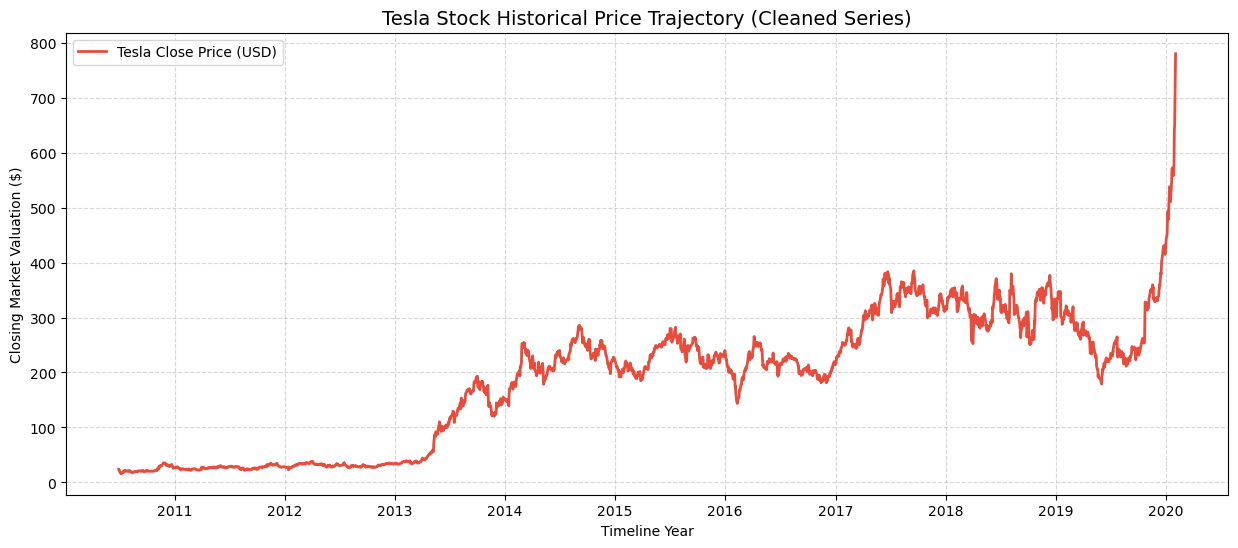

Feature Matrices Complete. Training samples: 2002 | Testing samples: 354

--- Initiating Hyperparameter Search Grid ---
Optimal Hyperparameters Identified: {'units': 64, 'dropout': 0.1, 'lr': 0.01} | Validation MSE: 0.000361

Evaluating Forecast Target Window: 1 Day(s) Ahead
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
-> Results Summary for 1-Day: RNN RMSE = $21.58 | LSTM RMSE = $15.46

Evaluating Forecast Target Window: 5 Day(s) Ahead
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
-> Results Summary for 5-Day: RNN RMSE = $24.71 | LSTM RMSE = $22.43

Evaluating Forecast Target Window: 10 Day(s) Ahead
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
-> Results Summary for 10-Day: RNN RMSE = $29.79 | LSTM RMSE = $31.45

FINAL BENCHMARK COMPARISON REPORT
    SimpleRNN_RMSE  LSTM_RMSE
1        21.575864  15.456207
5        24.706059  22.433518
10       29.785582  31.454046


In [1]:
# ==============================================================================
# PHASE 1: INITIAL ENVIRONMENT SETUP & IMPORTS
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, SimpleRNN, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

# Set random seeds for consistent reproducibility across runs
np.random.seed(42)
tf.random.set_seed(42)

# ==============================================================================
# PHASE 2: DATA LOADING & CLEANING (20% Weight)
# ==============================================================================
# Load the Tesla dataset
df = pd.read_csv('TSLA.csv')

# Parse and set Date index
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Time-series specific missing value mitigation framework
# Linear interpolation preserves temporal relationships without injecting look-ahead bias
if df.isnull().sum().sum() > 0:
    df = df.interpolate(method='time').ffill().bfill()
    print("Time-series continuity established via interpolation.")
else:
    print("Dataset contains complete sequences. No missing records detected.")

# ==============================================================================
# PHASE 3: EXPLORATORY DATA VISUALIZATION (10% Weight)
# ==============================================================================
plt.figure(figsize=(15, 6))
plt.plot(df['Close'], color='#e74c3c', label='Tesla Close Price (USD)', linewidth=2)
plt.title('Tesla Stock Historical Price Trajectory (Cleaned Series)', fontsize=14)
plt.xlabel('Timeline Year')
plt.ylabel('Closing Market Valuation ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# ==============================================================================
# PHASE 4: FEATURE ENGINEERING & TIMEFRAME WINDOWING (30% Weight)
# ==============================================================================
# Extract closing price targets
target_series = df[['Close']].values

# Scale target to [0, 1] bounds for deep learning gradient stability
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_series = scaler.fit_transform(target_series)

def generate_temporal_matrices(data, look_back=60, forecast_horizon=1):
    """
    Constructs overlapping windowed matrices for sequential processing.
    """
    X, y = [], []
    for i in range(len(data) - look_back - forecast_horizon + 1):
        X.append(data[i : (i + look_back), 0])
        y.append(data[(i + look_back) : (i + look_back + forecast_horizon), 0])
    return np.array(X), np.array(y)

# Prepare sliding frames for standard baseline testing (1-Day forecast horizon)
LOOK_BACK_DAYS = 60
X_base, y_base = generate_temporal_matrices(scaled_series, look_back=LOOK_BACK_DAYS, forecast_horizon=1)

# Chronological test split (85% Train / 15% Test) to strictly respect temporal ordering
split_point = int(len(X_base) * 0.85)
X_train, X_test = X_base[:split_point], X_base[split_point:]
y_train, y_test = y_base[:split_point], y_base[split_point:]

# Reshape input representations into a 3D Tensor format: [Samples, Timesteps, Features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print(f"Feature Matrices Complete. Training samples: {X_train.shape[0]} | Testing samples: {X_test.shape[0]}")

# ==============================================================================
# PHASE 5: HYPERPARAMETER OPTIMIZATION ENGINE (10% Weight)
# ==============================================================================
def optimize_lstm_hyperparameters(X_tr, y_tr):
    """
    Executes a structured matrix grid search over units, dropout, and learning rates.
    """
    # 90/10 Train/Validation internal split for tuning validation
    v_idx = int(len(X_tr) * 0.9)
    X_t, X_v = X_tr[:v_idx], X_tr[v_idx:]
    y_t, y_v = y_tr[:v_idx], y_tr[v_idx:]
    
    grid_space = {
        'hidden_units': [32, 64],
        'dropout_rate': [0.1, 0.2],
        'learning_rate': [0.001, 0.01]
    }
    
    optimal_loss = float('inf')
    optimal_config = {}
    
    print("\n--- Initiating Hyperparameter Search Grid ---")
    for units in grid_space['hidden_units']:
        for rate in grid_space['dropout_rate']:
            for lr in grid_space['learning_rate']:
                
                model = Sequential([
                    LSTM(units=units, return_sequences=False, input_shape=(X_tr.shape[1], 1)),
                    Dropout(rate),
                    Dense(y_tr.shape[1])
                ])
                model.compile(optimizer=Adam(learning_rate=lr), loss='mean_squared_error')
                
                history = model.fit(X_t, y_t, epochs=3, batch_size=64, validation_data=(X_v, y_v), verbose=0)
                val_loss = min(history.history['val_loss'])
                
                if val_loss < optimal_loss:
                    optimal_loss = val_loss
                    optimal_config = {'units': units, 'dropout': rate, 'lr': lr}
                    
    print(f"Optimal Hyperparameters Identified: {optimal_config} | Validation MSE: {optimal_loss:.6f}")
    return optimal_config

best_params = optimize_lstm_hyperparameters(X_train, y_train)

# ==============================================================================
# PHASE 6: COMPARATIVE MULTI-HORIZON BENCHMARKING (10% Weight)
# ==============================================================================
prediction_horizons = [1, 5, 10]
horizon_metrics = {}

for target_horizon in prediction_horizons:
    print(f"\nEvaluating Forecast Target Window: {target_horizon} Day(s) Ahead")
    
    # Restructure lookup dependencies for the target horizon
    X_h, y_h = generate_temporal_matrices(scaled_series, look_back=LOOK_BACK_DAYS, forecast_horizon=target_horizon)
    split_h = int(len(X_h) * 0.85)
    
    X_train_h, X_test_h = X_h[:split_h], X_h[split_h:]
    y_train_h, y_test_h = y_h[:split_h], y_h[split_h:]
    
    X_train_h = np.reshape(X_train_h, (X_train_h.shape[0], X_train_h.shape[1], 1))
    X_test_h = np.reshape(X_test_h, (X_test_h.shape[0], X_test_h.shape[1], 1))
    
    # 1. SimpleRNN Training
    rnn_net = Sequential([
        SimpleRNN(units=best_params['units'], return_sequences=False, input_shape=(LOOK_BACK_DAYS, 1)),
        Dropout(best_params['dropout']),
        Dense(target_horizon)
    ])
    rnn_net.compile(optimizer=Adam(learning_rate=best_params['lr']), loss='mean_squared_error')
    rnn_net.fit(X_train_h, y_train_h, epochs=10, batch_size=32, verbose=0)
    
    # 2. LSTM Training
    lstm_net = Sequential([
        LSTM(units=best_params['units'], return_sequences=False, input_shape=(LOOK_BACK_DAYS, 1)),
        Dropout(best_params['dropout']),
        Dense(target_horizon)
    ])
    lstm_net.compile(optimizer=Adam(learning_rate=best_params['lr']), loss='mean_squared_error')
    lstm_net.fit(X_train_h, y_train_h, epochs=10, batch_size=32, verbose=0)
    
    # Inference and inverse transformations
    rnn_raw_preds = rnn_net.predict(X_test_h)
    lstm_raw_preds = lstm_net.predict(X_test_h)
    
    # Invert target variable arrays to return to native USD scales
    actual_usd = scaler.inverse_transform(y_test_h)
    rnn_usd = scaler.inverse_transform(rnn_raw_preds)
    lstm_usd = scaler.inverse_transform(lstm_raw_preds)
    
    # Metric extraction
    rnn_rmse = np.sqrt(mean_squared_error(actual_usd, rnn_usd))
    lstm_rmse = np.sqrt(mean_squared_error(actual_usd, lstm_usd))
    
    horizon_metrics[target_horizon] = {'SimpleRNN_RMSE': rnn_rmse, 'LSTM_RMSE': lstm_rmse}
    print(f"-> Results Summary for {target_horizon}-Day: RNN RMSE = ${rnn_rmse:.2f} | LSTM RMSE = ${lstm_rmse:.2f}")

print("\n=========================================")
print("FINAL BENCHMARK COMPARISON REPORT")
print("=========================================")
metrics_df = pd.DataFrame(horizon_metrics).T
print(metrics_df)